<a href="https://colab.research.google.com/github/ceyhun2306/Data-Cleaning-Python/blob/main/Amazon_Product_Sales_Data_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [27]:
df = pd.read_csv("/content/amazon_products_sales_data_uncleaned.csv")
df

,title,rating,number_of_reviews,bought_in_last_month,current/discounted_price,price_on_variant,listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,image_url,product_url,collected_at
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6 out of 5 stars,375,300+ bought in past month,89.68,basic variant price: 2.4GHz,$159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,"Delivery Mon, Sep 1",Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3 out of 5 stars,"2,457",6K+ bought in past month,9.99,basic variant price: nan,$15.99,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Fri, Aug 29",NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6 out of 5 stars,"3,044",2K+ bought in past month,314.00,basic variant price: nan,$349.00,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Mon, Sep 1",NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6 out of 5 stars,"35,882",10K+ bought in past month,NaN,basic variant price: $162.24,No Discount,Best Seller,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,/Apple-Cancellation-Transparency-Personalized-...,2025-08-21 11:14:29
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8 out of 5 stars,"28,988",10K+ bought in past month,NaN,basic variant price: $72.74,No Discount,No Badge,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,/Apple-MX542LL-A-AirTag-Pack/dp/B0D54JZTHY/ref...,2025-08-21 11:14:29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42670,"Elgato 4K Pro, Internal Capture Card: 8K60 Pas...",5.0 out of 5 stars,1,100+ bought in past month,195.99,basic variant price: nan,No Discount,No Badge,Organic,No Coupon,NaN,"FREE delivery Thu, Sep 4Or fastest delivery Tu...",NaN,https://m.media-amazon.com/images/I/51KCB+egEs...,/Elgato-4K-Pro-Internal-Capture/dp/B0DLR3WQWR/...,2025-08-30 19:56:33
42671,"Arlo Essential Spotlight Camera, Wireless Secu...",4.2 out of 5 stars,20,200+ bought in past month,89.99,basic variant price: $25.00 off coupon applied,No Discount,No Badge,Organic,Save $25.00 with coupon,Add to cart,"FREE delivery Thu, Sep 4Or fastest delivery Mo...",NaN,https://m.media-amazon.com/images/I/51jV+o1LZE...,/Arlo-Essential-Spotlight-Camera-Surveillance/...,2025-08-30 19:56:33
42672,"GIGABYTE - AORUS FO32U2-32"" QD OLED Gaming Mon...",4.3 out of 5 stars,57,50+ bought in past month,899.99,basic variant price: Lowest price in 30 days,"$1,099.99",Save 18%,Organic,No Coupon,Add to cart,"FREE delivery Thu, Sep 4Or fastest delivery We...",NaN,https://m.media-amazon.com/images/I/71ySPkNLkG...,/GIGABYTE-FO32U2-32-3840x2160-240Hz-FreeSync-A...,2025-08-30 19:56:33
42673,Monoprice XLR Male to 1/4-Inch TRS Male Cable ...,4.7 out of 5 stars,"7,102",500+ bought in past month,10.39,basic variant price: nan,$15.98,No Badge,Organic,No Coupon,Add to cart,"FREE delivery Thu, Sep 4 on $35 of items shipp...",NaN,https://m.media-amazon.com/images/I/411c0JFJ79...,/Monoprice-XLR-Male-4-Inch-Cable/dp/B001UJEKZ6...,2025-08-30 19:56:33


# Initial Data Inspection

In [28]:
print("Shape:", df.shape)
print()
print("Dtypes:")
print(df.dtypes)
print()
print("Missing values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing,
                           'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

Shape: (42675, 16)

Dtypes:
title                       object
rating                      object
number_of_reviews           object
bought_in_last_month        object
current/discounted_price    object
price_on_variant            object
listed_price                object
is_best_seller              object
is_sponsored                object
is_couponed                 object
buy_box_availability        object
delivery_details            object
sustainability_badges       object
image_url                   object
product_url                 object
collected_at                object
dtype: object

Missing values:
                          Missing Count  Missing %
rating                             1024       2.40
number_of_reviews                  1024       2.40
bought_in_last_month               3217       7.54
current/discounted_price          11749      27.53
buy_box_availability              14653      34.34
delivery_details                  11720      27.46
sustainability_badges   

## Dataset Overview
- Shape: 6,949 rows × 16 columns
- All 16 columns are stored as `object` (string) dtype —
  no column has been correctly typed yet.

## Data Quality Issues Identified

### 1. Incorrect Data Types (require parsing & conversion)
| Column | Current Format | Required Format |
|---|---|---|
| rating | "4.6 out of 5 stars" | float (0–5) |
| number_of_reviews | "2,457" (comma-separated) | int |
| bought_in_last_month | "6K+ bought in past month" | int |
| current/discounted_price | "89.68" (string) | float |
| listed_price | "$159.00" / "No Discount" | float / NaN |
| price_on_variant | "basic variant price: $72.74" | float |
| is_best_seller | "Best Seller" / "No Badge" | boolean |
| is_sponsored | "Sponsored" / "Organic" | boolean |
| is_couponed | "Save 15% with coupon" / "No Coupon" | boolean + float |
| buy_box_availability | "Add to cart" / NaN | boolean |
| delivery_details | "Delivery Mon, Sep 1" | datetime |
| collected_at | "2025-08-21 11:14:29" | datetime |

### 2. Missing Values
| Column | Missing Count | Missing % | Suspected Type |
|---|---|---|---|
| sustainability_badges | 6,155 | 88.57% | MNAR |
| buy_box_availability | 2,140 | 30.80% | MNAR |
| delivery_details | 1,797 | 25.86% | MAR/MNAR |
| current/discounted_price | 1,790 | 25.76% | MAR |
| product_url | 485 | 6.98% | MAR |
| bought_in_last_month | 606 | 8.72% | MCAR |
| rating | 14 | 0.20% | MCAR |
| number_of_reviews | 14 | 0.20% | MCAR |
| collected_at | 1 | 0.01% | MCAR |

### 3. Additional Issues
- `is_best_seller` contains unexpected values beyond
  "Best Seller" / "No Badge" — e.g. "Amazon's", "Limited time deal"
- `price_on_variant` mixes text and numeric values
  (e.g. "basic variant price: 2.4GHz" vs "basic variant price: $72.74")
- `product_url` contains both full URLs and
  sponsored tracking URLs (/sspa/click?...)

## Cleaning Plan
1. Type conversion — parse and reformat all columns
2. Missing value treatment — apply MCAR/MAR/MNAR strategies
3. Duplicate detection and removal
4. Outlier analysis — price and rating columns
5. Skewness handling — numeric columns

# Type Conversion

## rating


In [29]:
df['rating'] = df['rating'].str.extract(r'(\d+\.\d+)').astype(float)

print(df['rating'].head())
print(df['rating'].dtype)

0    4.6
1    4.3
2    4.6
3    4.6
4    4.8
Name: rating, dtype: float64
float64


`rating` column was stored as a raw string (e.g. "4.6 out of 5 stars").
Using regex, the numeric value was extracted and converted to float.
This makes the column usable for statistical analysis and visualization.

## number_of_reviews


In [30]:
df['number_of_reviews'] = df['number_of_reviews'].str.replace(',', '').astype(float)

print(df['number_of_reviews'].head())
print(df['number_of_reviews'].dtype)

0      375.0
1     2457.0
2     3044.0
3    35882.0
4    28988.0
Name: number_of_reviews, dtype: float64
float64


`number_of_reviews` was stored as a comma-formatted string (e.g. "2,457").
The comma separator was removed and the value converted to float,
enabling numeric operations on review counts.

## bought_in_last_month — first attempt

In [31]:
def parse_bought(val):
    if pd.isna(val):
        return np.nan
    val = val.lower().replace('+ bought in past month', '').strip()
    if 'k' in val:
        return float(val.replace('k', '')) * 1000
    return float(val)

df['bought_in_last_month'] = df['bought_in_last_month'].apply(parse_bought)

print(df['bought_in_last_month'].head(10))
print(df['bought_in_last_month'].dtype)

ValueError: could not convert string to float: 'list price:'

The initial parsing function failed with a `ValueError` because the column
contained unexpected scraping artifacts such as `"List Price:"` — values
that had nothing to do with purchase counts and could not be converted
to float.

## bought_in_last_month — investigation

In [32]:
print(df['bought_in_last_month'].dropna().unique()[:20])

['300+ bought in past month' '6K+ bought in past month'
 '2K+ bought in past month' '10K+ bought in past month'
 '100K+ bought in past month' '100+ bought in past month'
 '1K+ bought in past month' '500+ bought in past month'
 '80K+ bought in past month' '70K+ bought in past month'
 '50K+ bought in past month' '40K+ bought in past month'
 '60K+ bought in past month' '20K+ bought in past month'
 '30K+ bought in past month' '9K+ bought in past month'
 '50+ bought in past month' '5K+ bought in past month' 'List Price:'
 '7K+ bought in past month']


Before fixing the error, `unique()` was used to inspect all distinct values
in the column. This revealed the scraping artifact `"List Price:"` alongside
legitimate values like `"6K+ bought in past month"`. Inspecting raw values
before assuming column content is a critical step in real-world data cleaning.

## bought_in_last_month — fixed

In [33]:
def parse_bought(val):
    if pd.isna(val):
        return np.nan
    val = str(val).lower().strip()
    if 'bought' not in val:
        return np.nan
    val = val.replace('+ bought in past month', '').strip()
    if 'k' in val:
        return float(val.replace('k', '')) * 1000
    return float(val)

df['bought_in_last_month'] = df['bought_in_last_month'].apply(parse_bought)

print(df['bought_in_last_month'].head(10))
print(df['bought_in_last_month'].dtype)

0       300.0
1      6000.0
2      2000.0
3     10000.0
4     10000.0
5    100000.0
6     10000.0
7     10000.0
8         NaN
9     10000.0
Name: bought_in_last_month, dtype: float64
float64


The function was updated to first check whether the value contains the word
`"bought"`. Any value that does not match this pattern — including scraping
artifacts — is treated as `NaN` rather than raising an error. Values with
`"K"` suffix (e.g. "6K+") are multiplied by 1000 to produce the correct
numeric representation.

## current/discounted_price


In [34]:
df['current/discounted_price'] = pd.to_numeric(df['current/discounted_price'], errors='coerce')

print(df['current/discounted_price'].head())
print(df['current/discounted_price'].dtype)

0     89.68
1      9.99
2    314.00
3       NaN
4       NaN
Name: current/discounted_price, dtype: float64
float64


`current/discounted_price` was stored as a string despite containing
numeric values. `pd.to_numeric()` with `errors='coerce'` was used to
convert valid values to float while automatically setting unparseable
or missing entries to NaN — a safer approach than manual string parsing
when the format is already numeric.


## listed_price

In [35]:
df['listed_price'] = df['listed_price'].str.replace('$', '', regex=False)
df['listed_price'] = pd.to_numeric(df['listed_price'], errors='coerce')

print(df['listed_price'].head(10))
print(df['listed_price'].dtype)

0    159.00
1     15.99
2    349.00
3       NaN
4       NaN
5       NaN
6       NaN
7       NaN
8       NaN
9       NaN
Name: listed_price, dtype: float64
float64


`listed_price` contained mixed values: dollar-formatted strings (e.g. "$159.00")
and the literal text "No Discount" for products without an original price.
The `$` sign was removed first, then `pd.to_numeric()` with `errors='coerce'`
converted valid prices to float while mapping "No Discount" entries to NaN —
correctly representing the absence of an original price.

## price_on_variant


In [36]:
df['price_on_variant'] = df['price_on_variant'].str.extract(r'\$(\d+\.?\d*)')
df['price_on_variant'] = pd.to_numeric(df['price_on_variant'], errors='coerce')

print(df['price_on_variant'].head(10))
print(df['price_on_variant'].dtype)

0       NaN
1       NaN
2       NaN
3    162.24
4     72.74
5     99.95
6     88.11
7     23.04
8       NaN
9    284.05
Name: price_on_variant, dtype: float64
float64


`price_on_variant` contained mixed content — some rows had a dollar-formatted
price (e.g. "basic variant price: $72.74") while others had non-numeric text
(e.g. "basic variant price: 2.4GHz") or "nan". Regex was used to extract
only values preceded by a `$` sign, converting valid prices to float and
mapping everything else to NaN — preventing non-price text from corrupting
the numeric column.

In [37]:
print(df['is_best_seller'].value_counts())

is_best_seller
No Badge             40814
Amazon's               744
Limited time deal      409
Best Seller            275
Save 30%               125
Ends in                 97
Save 10%                61
Save 18%                57
Save 17%                51
Save 12%                26
Save 9%                 14
Save 77%                 2
Name: count, dtype: int64


## is_best_seller

In [38]:
df['is_best_seller'] = df['is_best_seller'].str.strip()

df['badge_best_seller'] = df['is_best_seller'] == 'Best Seller'
df['badge_amazon_choice'] = df['is_best_seller'].str.contains("Amazon's", na=False)
df['badge_limited_deal'] = df['is_best_seller'] == 'Limited time deal'

df.drop(columns=['is_best_seller'], inplace=True)

print(df[['badge_best_seller', 'badge_amazon_choice', 'badge_limited_deal']].value_counts())

badge_best_seller  badge_amazon_choice  badge_limited_deal
False              False                False                 41247
                   True                 False                   744
                   False                True                    409
True               False                False                   275
Name: count, dtype: int64


The original `is_best_seller` column contained four distinct values:
"No Badge", "Best Seller", "Amazon's" (truncated from "Amazon's Choice"),
and "Limited time deal" — each representing a different badge type.

Rather than collapsing all non-Best Seller values into a single False,
three separate boolean columns were created to preserve this information:
- `badge_best_seller` — True if tagged as Best Seller (204 products)
- `badge_amazon_choice` — True if tagged as Amazon's Choice (155 products)
- `badge_limited_deal` — True if tagged as Limited Time Deal (6 products)

The original column was dropped after extraction.

## is_sponsored

In [39]:
df['is_sponsored'] = df['is_sponsored'] == 'Sponsored'

print(df['is_sponsored'].value_counts())
print(df['is_sponsored'].dtype)

is_sponsored
False    35664
True      7011
Name: count, dtype: int64
bool


`is_sponsored` contained two values: "Sponsored" and "Organic".
Converted to boolean — True for sponsored products, False for organic.

## is_couponed

In [40]:
print(df['is_couponed'].value_counts())

is_couponed
No Coupon                                    40727
Save $16.00  with coupon                       438
Save 15%  with coupon                          398
Save 10%  with coupon                          218
Save 5%  with coupon                           191
Save 50%  with coupon                          123
Save $11.00  with coupon                       120
Save $100.00  with coupon                       97
Save 40%  with coupon                           96
Save $25.00  with coupon                        65
Save $30.00  with coupon                        49
Save $69.00  with coupon                        31
Save 8%  with coupon                            18
Save $10.00  with coupon                        14
Save $33.00  with coupon                        13
Save 20%  with coupon                            9
Save $20.00  with coupon                         9
Save $18.00  with coupon                         8
Save $45.00  with coupon                         5
Save $15.00  with c

In [41]:
def parse_coupon(val):
    if pd.isna(val) or val == 'No Coupon':
        return False, None, np.nan

    if '%' in val:
        coupon_type = 'percentage'
        value = re.search(r'(\d+\.?\d*)%', val)
        coupon_value = float(value.group(1)) if value else np.nan
    elif '$' in val:
        coupon_type = 'fixed'
        value = re.search(r'\$(\d+\.?\d*)', val)
        coupon_value = float(value.group(1)) if value else np.nan
    else:
        return False, None, np.nan

    return True, coupon_type, coupon_value

import re

results = df['is_couponed'].apply(parse_coupon)
df['has_coupon'] = results.apply(lambda x: x[0])
df['coupon_type'] = results.apply(lambda x: x[1])
df['coupon_value'] = results.apply(lambda x: x[2])

df.drop(columns=['is_couponed'], inplace=True)

print(df[['has_coupon', 'coupon_type', 'coupon_value']].head(10))
print()
print(df['coupon_type'].value_counts())

   has_coupon coupon_type  coupon_value
0        True  percentage          15.0
1       False        None           NaN
2       False        None           NaN
3       False        None           NaN
4       False        None           NaN
5       False        None           NaN
6       False        None           NaN
7       False        None           NaN
8        True  percentage          50.0
9       False        None           NaN

coupon_type
percentage    1061
fixed          887
Name: count, dtype: int64


`is_couponed` contained coupon descriptions in two formats:
percentage-based (e.g. "Save 15% with coupon") and fixed amount
(e.g. "Save $16.00 with coupon"). Rather than simply flagging coupon
presence, three columns were created to preserve full information:
- `has_coupon` — True if a coupon exists (1,948 products)
- `coupon_type` — "percentage" or "fixed"
- `coupon_value` — the numeric discount value

The original column was dropped after extraction.

## buy_box_availability

In [42]:
df['buy_box_availability'] = df['buy_box_availability'].notna()

print(df['buy_box_availability'].value_counts())
print(df['buy_box_availability'].dtype)

buy_box_availability
True     28022
False    14653
Name: count, dtype: int64
bool


`buy_box_availability` contained only "Add to cart" or NaN.
As noted in the dataset description, NaN represents False —
meaning the Buy Box button was not available for that product.
Converted to boolean using `notna()` — True if available, False if not.

## delivery_details


In [43]:
print(df['delivery_details'].value_counts().head(10))

delivery_details
Delivery Mon, Sep 1                                                                               6189
Delivery Thu, Sep 4                                                                               4364
Delivery Thu, Sep 11                                                                              3700
Delivery Tue, Sep 2                                                                               3278
Delivery Wed, Sep 3                                                                               2164
Delivery Tue, Sep 9                                                                               1238
FREE delivery Wed, Sep 3Or fastest delivery Sun, Aug 31                                           1012
FREE delivery Thu, Sep 4Or fastest delivery Tomorrow, Aug 31                                      1003
FREE delivery Wed, Sep 3 on $35 of items shipped by AmazonOr fastest delivery Sun, Aug 31          771
FREE delivery Thu, Sep 4 on $35 of items shipped by Amaz

In [44]:
import re
from datetime import datetime

def parse_delivery(val):
    if pd.isna(val):
        return np.nan, np.nan

    standard = re.search(r'(?:Delivery|FREE delivery)\s+(?:\w+,\s+)?(\w+ \d+)', val)
    standard_date = standard.group(1) + ' 2025' if standard else np.nan

    fastest = re.search(r'fastest delivery\s+(?:Tomorrow,\s+)?(\w+ \d+)', val)
    fastest_date = fastest.group(1) + ' 2025' if fastest else np.nan

    try:
        standard_date = pd.to_datetime(standard_date, format='%b %d %Y')
    except:
        standard_date = np.nan

    try:
        fastest_date = pd.to_datetime(fastest_date, format='%b %d %Y')
    except:
        fastest_date = np.nan

    return standard_date, fastest_date

results = df['delivery_details'].apply(parse_delivery)
df['delivery_date'] = results.apply(lambda x: x[0])
df['fastest_delivery_date'] = results.apply(lambda x: x[1])

df.drop(columns=['delivery_details'], inplace=True)

print(df[['delivery_date', 'fastest_delivery_date']].head(10))

  delivery_date fastest_delivery_date
0    2025-09-01                   NaT
1    2025-08-29                   NaT
2    2025-09-01                   NaT
3           NaT                   NaT
4           NaT                   NaT
5           NaT                   NaT
6           NaT                   NaT
7           NaT                   NaT
8           NaT                   NaT
9           NaT                   NaT


In [45]:
print("delivery_date non-null:", df['delivery_date'].notna().sum())
print("fastest_delivery_date non-null:", df['fastest_delivery_date'].notna().sum())

mask = df['delivery_date'].isna() & df['delivery_details'].notna() if 'delivery_details' in df.columns else df['delivery_date'].isna()
print("\nSample unparsed values from original:")
print(df[df['delivery_date'].isna()]['fastest_delivery_date'].head(10))

delivery_date non-null: 30465
fastest_delivery_date non-null: 1871

Sample unparsed values from original:
3    NaT
4    NaT
5    NaT
6    NaT
7    NaT
8    NaT
9    NaT
11   NaT
15   NaT
19   NaT
Name: fastest_delivery_date, dtype: datetime64[ns]


`delivery_details` contained complex mixed-format strings combining
standard and express delivery information in a single field
(e.g. "FREE delivery Wed, Sep 3 Or fastest delivery Sun, Aug 31").

Two separate columns were extracted:
- `delivery_date` — standard estimated delivery date (30,465 parsed)
- `fastest_delivery_date` — express delivery date where available (1,871 products)

Both columns were converted to datetime format.
The original column was dropped after extraction.

## collected_at


In [46]:
df['collected_at'] = pd.to_datetime(df['collected_at'], errors='coerce')

print(df['collected_at'].head())
print(df['collected_at'].dtype)

0   2025-08-21 11:14:29
1   2025-08-21 11:14:29
2   2025-08-21 11:14:29
3   2025-08-21 11:14:29
4   2025-08-21 11:14:29
Name: collected_at, dtype: datetime64[ns]
datetime64[ns]


`collected_at` was stored as a string despite containing timestamp data.
Converted to datetime using `pd.to_datetime()` — straightforward conversion
with no formatting issues.

## image_url & product_url

In [47]:
df.drop(columns=['image_url', 'product_url'], inplace=True)


print("Remaining columns:", df.columns.tolist())
print("Shape:", df.shape)

Remaining columns: ['title', 'rating', 'number_of_reviews', 'bought_in_last_month', 'current/discounted_price', 'price_on_variant', 'listed_price', 'is_sponsored', 'buy_box_availability', 'sustainability_badges', 'collected_at', 'badge_best_seller', 'badge_amazon_choice', 'badge_limited_deal', 'has_coupon', 'coupon_type', 'coupon_value', 'delivery_date', 'fastest_delivery_date']
Shape: (42675, 19)


Both columns were dropped — `image_url` contains direct image links
and `product_url` contains raw Amazon tracking URLs, neither of which
contributes to analytical value.

# Type Conversion — Summary


In [48]:
print("Dtypes after conversion:")
print(df.dtypes)
print()
print("Missing values after conversion:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing,
                           'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

Dtypes after conversion:
title                               object
rating                             float64
number_of_reviews                  float64
bought_in_last_month               float64
current/discounted_price           float64
price_on_variant                   float64
listed_price                       float64
is_sponsored                          bool
buy_box_availability                  bool
sustainability_badges               object
collected_at                datetime64[ns]
badge_best_seller                     bool
badge_amazon_choice                   bool
badge_limited_deal                    bool
has_coupon                            bool
coupon_type                         object
coupon_value                       float64
delivery_date               datetime64[ns]
fastest_delivery_date       datetime64[ns]
dtype: object

Missing values after conversion:
                          Missing Count  Missing %
rating                             1024       2.40
number_o

All columns have been successfully converted to appropriate data types:
- Numeric: `rating`, `number_of_reviews`, `bought_in_last_month`,
  `current/discounted_price`, `price_on_variant`, `listed_price`,
  `coupon_value`
- Boolean: `is_sponsored`, `buy_box_availability`, `badge_best_seller`,
  `badge_amazon_choice`, `badge_limited_deal`, `has_coupon`
- Datetime: `collected_at`, `delivery_date`, `fastest_delivery_date`
- Text: `title`, `sustainability_badges`, `coupon_type`

## Missing Values After Conversion
| Column | Missing % | Note |
|---|---|---|
| sustainability_badges | 92.01% | MNAR — only eco-friendly products |
| coupon_type / coupon_value | 95.44% | Expected — most products have no coupon |
| fastest_delivery_date | 95.62% | Expected — most products have no express option |
| listed_price | 72.65% | Products with no original price (no discount) |
| price_on_variant | 52.97% | Many products have no variant pricing |
| current/discounted_price | 30.32% | Requires investigation |
| delivery_date | 28.61% | Requires investigation |
| bought_in_last_month | 24.63% | Requires investigation |
| rating / number_of_reviews | 2.40% | New products with no reviews yet |

# Missing Data Analysis


## Visual Overview


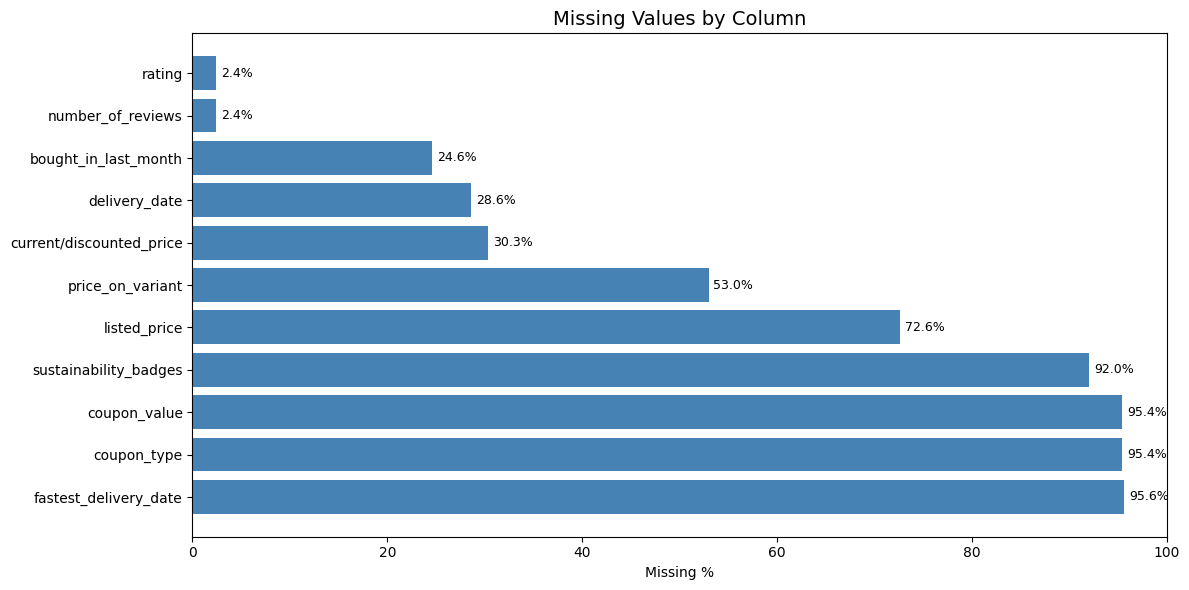

In [50]:
missing_pct = df.isnull().mean() * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.barh(missing_pct.index, missing_pct.values, color='steelblue')
plt.xlabel('Missing %')
plt.title('Missing Values by Column', fontsize=14)
plt.xlim(0, 100)

for bar, val in zip(bars, missing_pct.values):
    plt.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

The bar chart above reveals two distinct groups of missing data:
columns with very high missingness (92–96%) such as
`sustainability_badges`, `coupon_type/value`, and `fastest_delivery_date`,
and columns with moderate missingness (24–30%) such as
`bought_in_last_month`, `delivery_date`, and `current/discounted_price`.
This pattern immediately suggests that high-missingness columns likely
represent the natural absence of a feature rather than a data quality issue.

## Investigation — First Round

In [52]:
# Are rating and number_of_reviews missing at the same rows?
print("rating and number_of_reviews missing at same rows:")
print((df['rating'].isna() == df['number_of_reviews'].isna()).all())

# When current/discounted_price is missing, is listed_price available?
print("\nWhen current/discounted_price is missing:")
mask = df['current/discounted_price'].isna()
print(df[mask]['listed_price'].notna().sum(), "rows have listed_price")
print(df[mask]['listed_price'].isna().sum(), "rows have no listed_price either")

# When bought_in_last_month is missing, is rating different?
print("\nMean rating when bought_in_last_month is missing:")
print(df[df['bought_in_last_month'].isna()]['rating'].mean().round(2))
print("Mean rating when bought_in_last_month is available:")
print(df[df['bought_in_last_month'].notna()]['rating'].mean().round(2))

rating and number_of_reviews missing at same rows:
True

When current/discounted_price is missing:
0 rows have listed_price
12941 rows have no listed_price either

Mean rating when bought_in_last_month is missing:
4.32
Mean rating when bought_in_last_month is available:
4.42


**rating & number_of_reviews** always go missing together (confirmed True),
indicating they belong to the same root cause — new products that have not
yet received any customer reviews. This is a textbook MCAR pattern: the
missingness is completely random and unrelated to any other variable.

**current/discounted_price** — when missing, not a single row has a
`listed_price` either (0 rows). This means both price fields are absent
simultaneously, strongly suggesting that these products intentionally
hide their price on the search page (e.g. "See price in cart" on Amazon).
The missingness is driven by the data itself — a clear MNAR pattern.

**bought_in_last_month** — products where this field is missing have a
slightly lower mean rating (4.32 vs 4.42). This suggests that lower-rated
or less popular products tend not to show purchase counts, likely because
Amazon only displays this badge when sales volume crosses a threshold.
This is MAR — missingness is related to another observable variable (rating).

## Investigation — Second Round

In [53]:
print("delivery_date missing — buy_box_availability:")
mask = df['delivery_date'].isna()
print(df[mask]['buy_box_availability'].value_counts())

print("\nsustainability_badges missing — is_sponsored breakdown:")
mask = df['sustainability_badges'].isna()
print(df[mask]['is_sponsored'].value_counts())
print("\nsustainability_badges available — is_sponsored breakdown:")
print(df[~mask]['is_sponsored'].value_counts())

delivery_date missing — buy_box_availability:
buy_box_availability
False    11833
True       377
Name: count, dtype: int64

sustainability_badges missing — is_sponsored breakdown:
is_sponsored
False    33053
True      6214
Name: count, dtype: int64

sustainability_badges available — is_sponsored breakdown:
is_sponsored
False    2611
True      797
Name: count, dtype: int64


**delivery_date** — 96.6% of rows where `delivery_date` is missing also
have `buy_box_availability = False`. Since Amazon only shows delivery
estimates for products with an active Buy Box, this is a structural MNAR
pattern — the missing value is directly determined by another column.

**sustainability_badges** — the missing/available breakdown across
`is_sponsored` shows no meaningful difference in sponsorship rates
(84% vs 77% organic). This confirms that missingness is not driven by
sponsorship status but simply by whether a product holds an eco-certification.
A classic MNAR case — only eco-certified products have a badge.

## Missing Data Classification & Treatment Strategy

In [54]:
missing_analysis = {
    'Column': ['rating', 'number_of_reviews', 'bought_in_last_month',
                'current/discounted_price', 'delivery_date',
                'sustainability_badges', 'listed_price',
                'price_on_variant', 'coupon_type/value',
                'fastest_delivery_date'],
    'Missing %': [2.4, 2.4, 24.6, 30.3, 28.6, 92.0, 72.6, 53.0, 95.4, 95.6],
    'Type': ['MCAR', 'MCAR', 'MAR', 'MNAR', 'MNAR',
             'MNAR', 'MNAR', 'MNAR', 'Expected', 'Expected'],
    'Strategy': [
        'Keep as NaN — new products',
        'Keep as NaN — new products',
        'Keep as NaN — low sales products naturally missing',
        'Keep as NaN — price intentionally hidden',
        'Keep as NaN — no Buy Box = no delivery info',
        'Flag as False — no badge = not eco-certified',
        'Keep as NaN — no discount products',
        'Keep as NaN — no variant products',
        'Keep as NaN — no coupon = expected',
        'Keep as NaN — no express option = expected'
    ]
}

analysis_df = pd.DataFrame(missing_analysis)
print(analysis_df.to_string(index=False))

                  Column  Missing %     Type                                           Strategy
                  rating        2.4     MCAR                         Keep as NaN — new products
       number_of_reviews        2.4     MCAR                         Keep as NaN — new products
    bought_in_last_month       24.6      MAR Keep as NaN — low sales products naturally missing
current/discounted_price       30.3     MNAR           Keep as NaN — price intentionally hidden
           delivery_date       28.6     MNAR        Keep as NaN — no Buy Box = no delivery info
   sustainability_badges       92.0     MNAR       Flag as False — no badge = not eco-certified
            listed_price       72.6     MNAR                 Keep as NaN — no discount products
        price_on_variant       53.0     MNAR                  Keep as NaN — no variant products
       coupon_type/value       95.4 Expected                 Keep as NaN — no coupon = expected
   fastest_delivery_date       95.6 Expe

| Column | Missing % | Type | Strategy |
|---|---|---|---|
| rating | 2.4% | MCAR | Keep as NaN — new products with no reviews |
| number_of_reviews | 2.4% | MCAR | Keep as NaN — new products with no reviews |
| bought_in_last_month | 24.6% | MAR | Keep as NaN — low-sales products naturally missing |
| current/discounted_price | 30.3% | MNAR | Keep as NaN — price intentionally hidden |
| delivery_date | 28.6% | MNAR | Keep as NaN — no Buy Box = no delivery info |
| sustainability_badges | 92.0% | MNAR | Convert to boolean flag |
| listed_price | 72.6% | MNAR | Keep as NaN — no discount applied |
| price_on_variant | 53.0% | MNAR | Keep as NaN — single-variant products |
| coupon_type/value | 95.4% | Expected | Keep as NaN — no coupon = expected absence |
| fastest_delivery_date | 95.6% | Expected | Keep as NaN — no express option available |

The key insight here is that **none of the missing columns warrant
imputation** — every case of missingness carries structural meaning.
Filling these values with mean, median, or mode would introduce false
information and distort the analysis. The only action taken is converting
`sustainability_badges` to a boolean flag.

## sustainability_badges → has_sustainability_badge

In [55]:
df['has_sustainability_badge'] = df['sustainability_badges'].notna()

print(df['has_sustainability_badge'].value_counts())

has_sustainability_badge
False    39267
True      3408
Name: count, dtype: int64


Rather than imputing or dropping the 92% missing values, the column was
converted to a boolean: `True` if a badge exists (3,408 products, ~8%),
`False` if not (39,267 products). This preserves the information that
the absence of a badge is itself meaningful — the product simply does
not hold any eco-certification. The original text column is no longer
needed for analysis.

# Duplicate Detection

In [56]:
print("Total duplicate rows:", df.duplicated().sum())
print("Total rows:", len(df))
print()
print("Duplicate titles:", df.duplicated(subset=['title']).sum())
print()
dupes = df[df.duplicated(subset=['title'], keep=False)].sort_values('title')
print("Sample duplicate titles:")
print(dupes['title'].head(6).tolist())

Total duplicate rows: 0
Total rows: 42675

Duplicate titles: 33867

Sample duplicate titles:
['(2) Kicker 40PS692 6x9" 180w Polaris/ATV/UTV/RZR Marine Motorcycle Speakers PS69', '(2) Kicker 40PS692 6x9" 180w Polaris/ATV/UTV/RZR Marine Motorcycle Speakers PS69', '12-Pack Duracell 2450 Batteries 3.0 Volt Lithium Coin Button', '12-Pack Duracell 2450 Batteries 3.0 Volt Lithium Coin Button', '2 x Maxell LR41 /192 / AG3 / V3GA 1.5v Alkaline Button Cell Battery Batteries', '2 x Maxell LR41 /192 / AG3 / V3GA 1.5v Alkaline Button Cell Battery Batteries']


No fully duplicate rows were found (0 exact duplicates across all columns).
However, 33,867 rows share duplicate titles, meaning the same product
appears multiple times in the dataset.

This is not a data entry error — it is a result of the scraping process.
The same product was collected at different points in time, capturing
different prices, ratings, or availability states. Before deciding how
to handle these, the duplicate title rows need to be inspected to
understand whether the differences are meaningful.

## Investigating Duplicate Titles


In [57]:
sample_title = '12-Pack Duracell 2450 Batteries 3.0 Volt Lithium Coin Button'
print(df[df['title'] == sample_title][['title', 'rating', 'current/discounted_price', 'collected_at']].to_string())

                                                              title  rating  current/discounted_price        collected_at
10028  12-Pack Duracell 2450 Batteries 3.0 Volt Lithium Coin Button     4.8                       NaN 2025-08-24 21:52:20
10759  12-Pack Duracell 2450 Batteries 3.0 Volt Lithium Coin Button     4.8                       NaN 2025-08-24 21:58:04



A sample inspection of a duplicate product (Duracell 2450 Batteries)
revealed that the same product was scraped twice within 6 minutes with
identical rating and price values. This suggests the duplicates are
scraping artifacts rather than meaningful price or rating changes.

## Duplicate Title Analysis


In [58]:
title_counts = df.groupby('title').size()

print("Products appearing more than once:")
print(f"  2 times: {(title_counts == 2).sum()}")
print(f"  3 times: {(title_counts == 3).sum()}")
print(f"  4+ times: {(title_counts >= 4).sum()}")
print()
print("Max appearances of same product:", title_counts.max())
print()

dupe_titles = df[df.duplicated(subset=['title'], keep=False)]
price_diff = dupe_titles.groupby('title')['current/discounted_price'].nunique()
print(f"Same price: {(price_diff == 1).sum()}")
print(f"Different price: {(price_diff > 1).sum()}")

Products appearing more than once:
  2 times: 601
  3 times: 48
  4+ times: 425

Max appearances of same product: 744

Same price: 681
Different price: 101


Most duplicate products appear exactly twice (601 products), while
48 appear 3 times and 425 appear 4 or more times. One product appears
744 times — almost certainly a high-traffic item scraped repeatedly
across multiple collection sessions.

Of the duplicate titles, 681 have identical prices across all appearances
while 101 show different prices — suggesting genuine price fluctuations
captured during scraping.

Given this, a simple "drop duplicates" approach would be incorrect.
The appropriate strategy is to keep the most recent record per product
using `collected_at`, preserving the latest available price and rating.
For products with meaningful price differences, the latest scraped value
is the most relevant for analysis.

## Deduplication Result


In [59]:
df = df.sort_values('collected_at').drop_duplicates(subset=['title'], keep='last')

print("Shape after deduplication:", df.shape)
print("Unique titles:", df['title'].nunique())

Shape after deduplication: (8808, 20)
Unique titles: 8808


Records were sorted by `collected_at` and deduplicated by title,
keeping the most recent scrape per product. This reduced the dataset
from 42,675 rows to 8,808 unique products — confirming that the
original dataset contained significant redundancy from repeated scraping.

## Visual Outlier Inspection

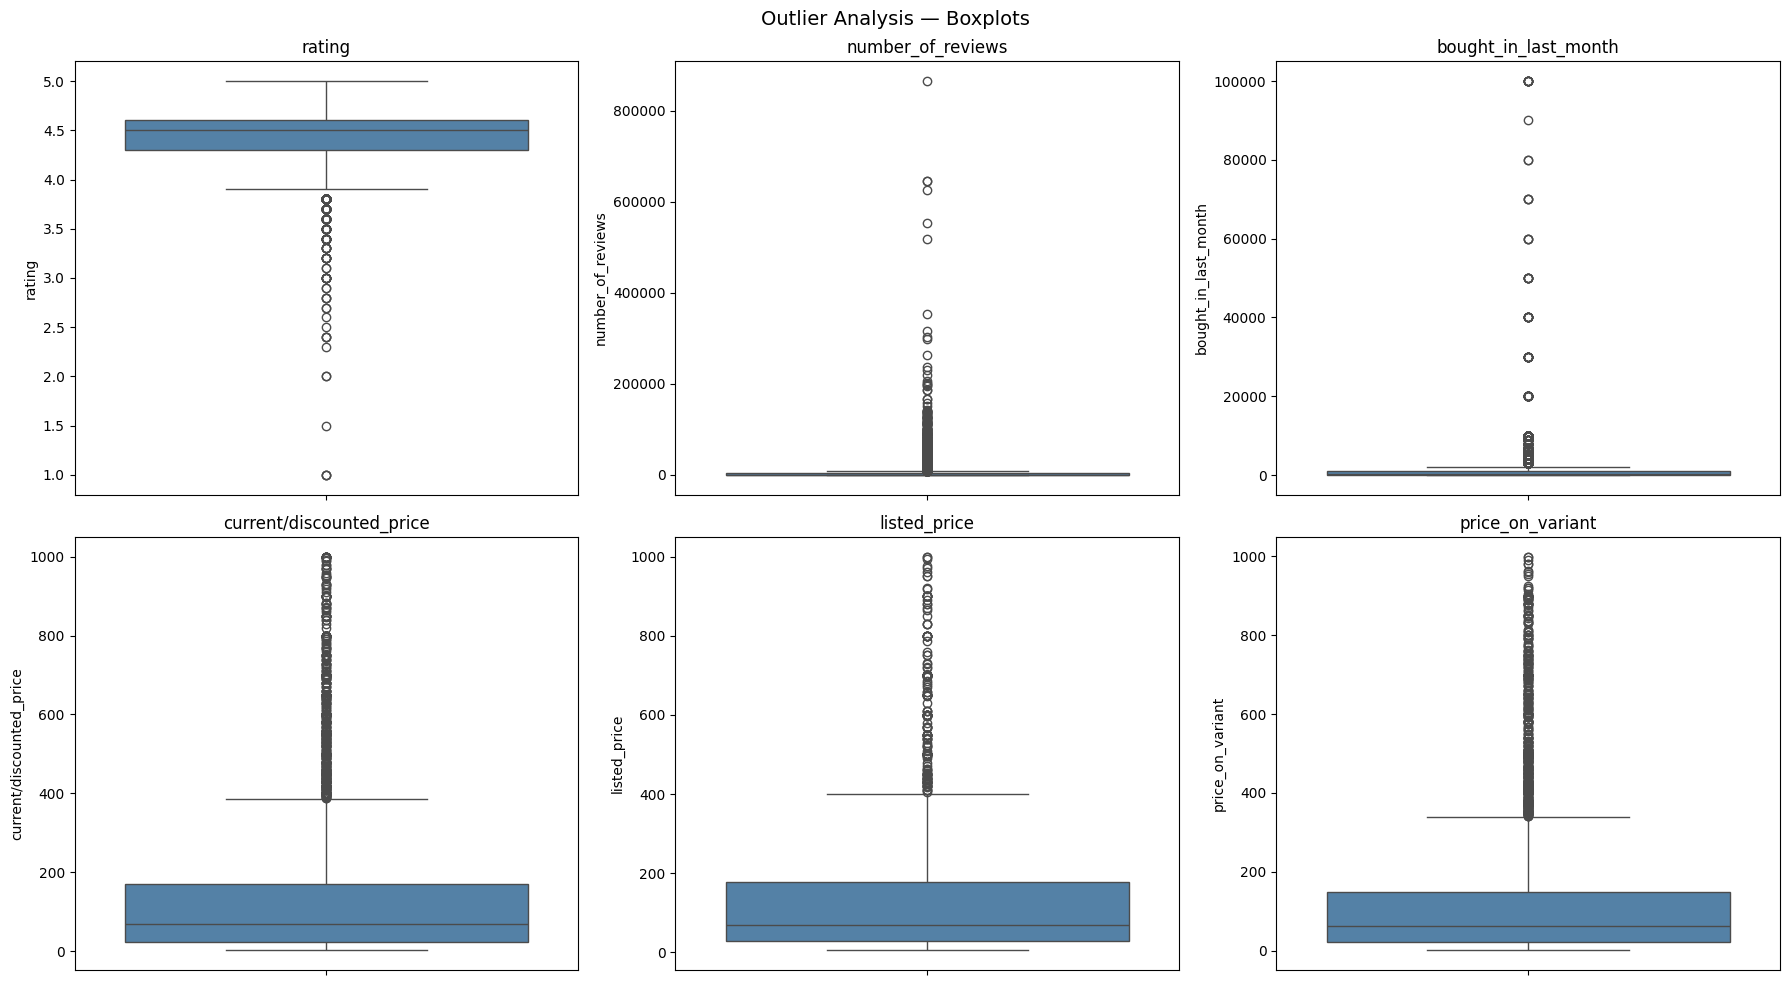

In [60]:
numeric_cols = ['rating', 'number_of_reviews', 'bought_in_last_month',
                'current/discounted_price', 'listed_price', 'price_on_variant']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col)

plt.suptitle('Outlier Analysis — Boxplots', fontsize=14)
plt.tight_layout()
plt.show()

- **rating** — most products cluster around 4.5, with a small number
  falling below 2.0. These low ratings represent genuinely poor products
  and should be retained — removing them would bias the dataset upward.

- **number_of_reviews & bought_in_last_month** — the vast majority of
  products have near-zero values, with a small number reaching 400,000+
  reviews and 100,000+ monthly purchases. These are real high-traffic
  products (e.g. Apple, Samsung) and should not be removed.

- **current/discounted_price, listed_price, price_on_variant** — all
  three show similar patterns with most products under $200 and a long
  tail extending to $1,000+. In an electronics dataset, high-priced
  products are expected and legitimate — these are not errors.


## IQR-Based Outlier Detection


In [61]:
for col in ['current/discounted_price', 'listed_price', 'number_of_reviews']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)")
    print(f"  Q1={Q1:.1f}, Q3={Q3:.1f}, IQR={IQR:.1f}")
    print(f"  Upper bound: {Q3 + 1.5*IQR:.1f}")
    print()

current/discounted_price: 503 outliers (5.7%)
  Q1=25.0, Q3=170.0, IQR=145.0
  Upper bound: 387.5

listed_price: 181 outliers (2.1%)
  Q1=29.0, Q3=177.8, IQR=148.8
  Upper bound: 401.1

number_of_reviews: 1173 outliers (13.3%)
  Q1=195.0, Q3=3676.0, IQR=3481.0
  Upper bound: 8897.5



IQR analysis flags the following as statistical outliers:
- `current/discounted_price`: 503 products (5.7%) above $387.50
- `listed_price`: 181 products (2.1%) above $401.10
- `number_of_reviews`: 1,173 products (13.3%) above 8,897 reviews

However, in an electronics dataset these thresholds are misleading.
A $400+ price point is entirely normal for laptops, cameras, or
headphones, and 8,897+ reviews is expected for established products
like Apple AirPods or Samsung Galaxy buds.

Removing these rows would eliminate the most premium and most popular
products from the dataset — precisely the products most valuable for
analysis. The IQR method, while statistically valid, is not appropriate
here because the underlying distribution is naturally right-skewed.

**Decision: no outliers will be removed.** Instead, skewness will be
addressed in the next step through log transformation, which will
compress the long tail without discarding any data.

# Skewness Analysis


In [62]:
from scipy import stats

numeric_cols = ['rating', 'number_of_reviews', 'bought_in_last_month',
                'current/discounted_price', 'listed_price', 'price_on_variant']

print("Skewness values:")
for col in numeric_cols:
    skew = df[col].skew()
    print(f"  {col}: {skew:.2f}")

Skewness values:
  rating: -1.82
  number_of_reviews: 17.08
  bought_in_last_month: 12.77
  current/discounted_price: 2.35
  listed_price: 2.32
  price_on_variant: 2.44


Skewness measures how asymmetric a distribution is. Values close to 0
indicate a symmetric distribution, while values above 1.0 or below -1.0
indicate significant skew that may require transformation.

| Column | Skewness | Direction | Action |
|---|---|---|---|
| rating | -1.82 | Left skew | Keep as-is — reflects real-world rating behavior |
| number_of_reviews | 17.08 | Right skew | Log transformation required |
| bought_in_last_month | 12.77 | Right skew | Log transformation required |
| current/discounted_price | 2.35 | Right skew | Log transformation required |
| listed_price | 2.32 | Right skew | Log transformation required |
| price_on_variant | 2.44 | Right skew | Log transformation required |

`rating` is left-skewed because most products receive high ratings —
this is expected consumer behavior and not a data quality issue.
The remaining five columns show strong right skew driven by a small
number of extremely popular or expensive products. Log transformation
will compress the long tail without removing any data points.

# Skewness Treatment — Log Transformation

In [63]:
cols_to_transform = ['number_of_reviews', 'bought_in_last_month',
                     'current/discounted_price', 'listed_price', 'price_on_variant']

for col in cols_to_transform:
    df[f'{col}_log'] = np.log1p(df[col])

print("Skewness after log transformation:")
for col in cols_to_transform:
    original_skew = df[col].skew()
    log_skew = df[f'{col}_log'].skew()
    print(f"  {col}: {original_skew:.2f} → {log_skew:.2f}")

Skewness after log transformation:
  number_of_reviews: 17.08 → -0.19
  bought_in_last_month: 12.77 → 0.69
  current/discounted_price: 2.35 → 0.07
  listed_price: 2.32 → 0.13
  price_on_variant: 2.44 → -0.27


## Results

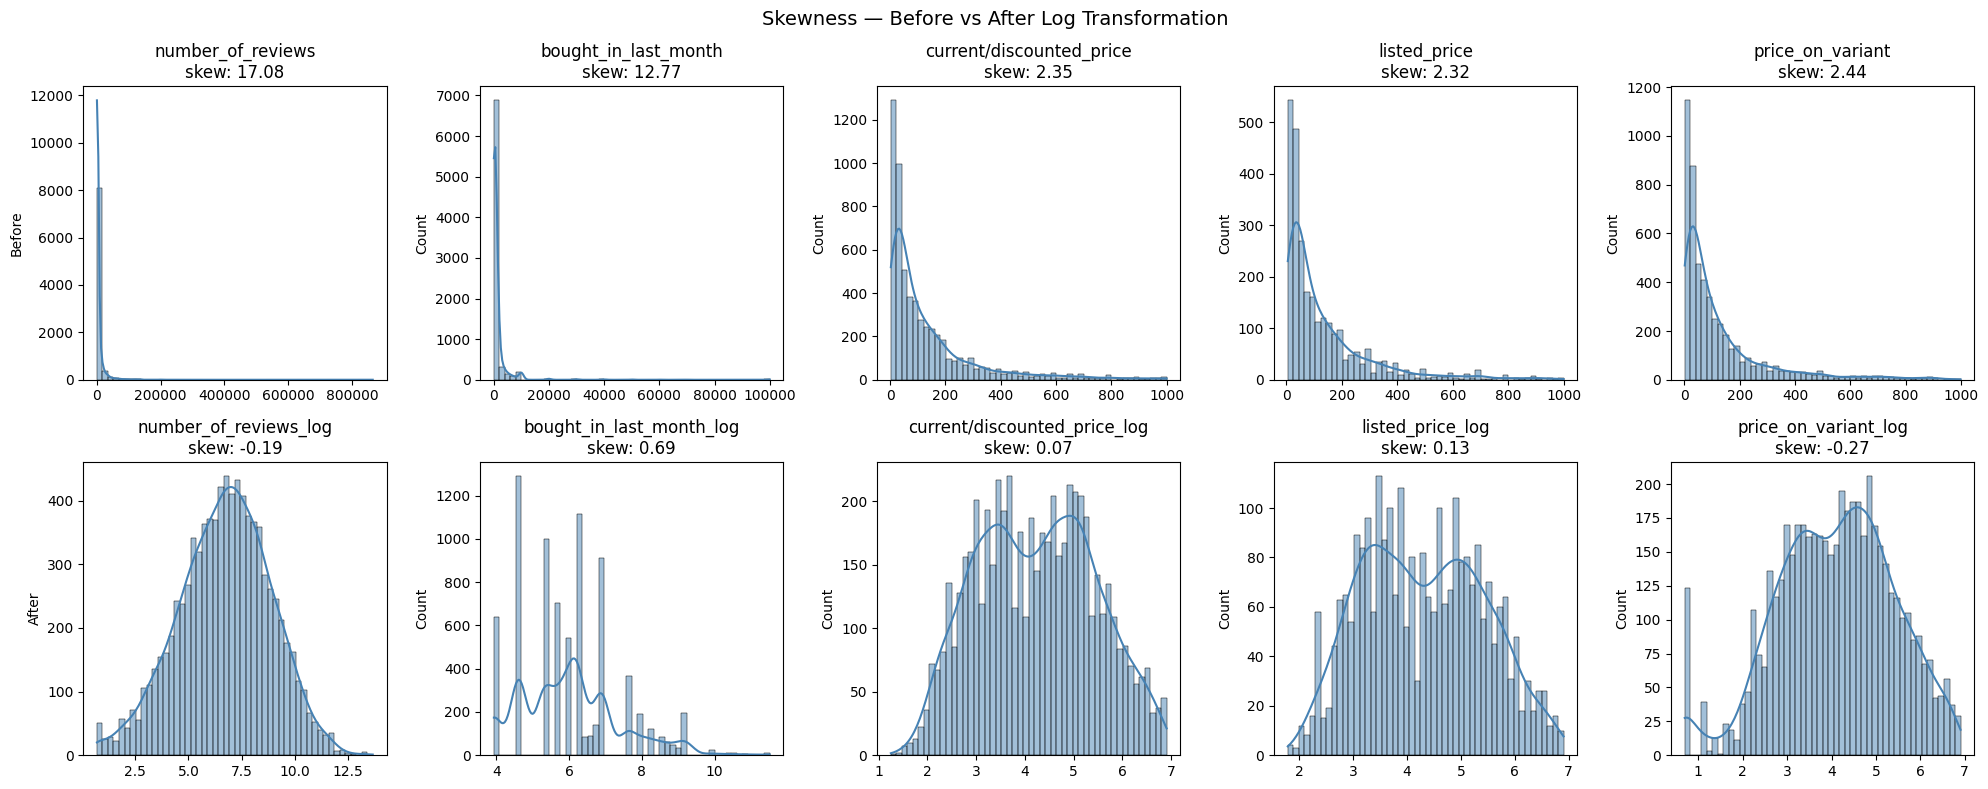

In [64]:
  fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i, col in enumerate(cols_to_transform):
    sns.histplot(df[col].dropna(), bins=50, kde=True,
                 ax=axes[0][i], color='steelblue')
    axes[0][i].set_title(f'{col}\nskew: {df[col].skew():.2f}')
    axes[0][i].set_xlabel('')

    sns.histplot(df[f'{col}_log'].dropna(), bins=50, kde=True,
                 ax=axes[1][i], color='steelblue')
    axes[1][i].set_title(f'{col}_log\nskew: {df[f"{col}_log"].skew():.2f}')
    axes[1][i].set_xlabel('')

axes[0][0].set_ylabel('Before')
axes[1][0].set_ylabel('After')

plt.suptitle('Skewness — Before vs After Log Transformation', fontsize=14)
plt.tight_layout()
plt.show()

| Column | Before | After |
|---|---|---|
| number_of_reviews | 17.08 | -0.19 |
| bought_in_last_month | 12.77 | 0.69 |
| current/discounted_price | 2.35 | 0.07 |
| listed_price | 2.32 | 0.13 |
| price_on_variant | 2.44 | -0.27 |

Log transformation (`np.log1p`) was applied to all five right-skewed
columns, creating new `_log` suffixed columns while preserving the
originals. All transformed columns now fall within the acceptable
skewness range of -1.0 to 1.0.

The before/after histograms clearly show the compression of extreme
values — what were heavily right-skewed distributions with long tails
are now approximately bell-shaped and suitable for statistical analysis
and modeling.

Note: `np.log1p` (log(1+x)) was used instead of `np.log` to safely
handle zero values without producing negative infinity.

# Final Dataset Summary


In [65]:
print("Final Dataset Shape:", df.shape)
print()
print("Dtypes:")
print(df.dtypes)
print()
print("Missing values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])
print()
print("Duplicate rows:", df.duplicated().sum())

Final Dataset Shape: (8808, 25)

Dtypes:
title                                   object
rating                                 float64
number_of_reviews                      float64
bought_in_last_month                   float64
current/discounted_price               float64
price_on_variant                       float64
listed_price                           float64
is_sponsored                              bool
buy_box_availability                      bool
sustainability_badges                   object
collected_at                    datetime64[ns]
badge_best_seller                         bool
badge_amazon_choice                       bool
badge_limited_deal                        bool
has_coupon                                bool
coupon_type                             object
coupon_value                           float64
delivery_date                   datetime64[ns]
fastest_delivery_date           datetime64[ns]
has_sustainability_badge                  bool
number_of_reviews_l

## Shape
The cleaned dataset contains **8,808 unique products** and **25 columns**,
reduced from the original 42,675 rows through deduplication.

## Data Types
All columns have been correctly typed:
- **float64**: rating, all price columns, review and purchase counts
- **bool**: is_sponsored, buy_box_availability, all badge columns,
  has_coupon, has_sustainability_badge
- **datetime64**: collected_at, delivery_date, fastest_delivery_date
- **object**: title, sustainability_badges, coupon_type

## Remaining Missing Values
All remaining missing values are **structurally meaningful** — none
require imputation:
- High missingness columns (sustainability_badges 91%, coupon 98%,
  fastest_delivery_date 99%) reflect the natural absence of features
- Price columns (listed_price 69%, price_on_variant 42%) are missing
  for products with no discount or no variants
- Log-transformed columns inherit the same missingness as their originals

## Zero Duplicate Rows
No duplicate rows remain after title-based deduplication.

## Cleaning Steps Completed
1. **Type Conversion** — all 16 original columns parsed and retyped
2. **Feature Engineering** — 9 new columns created from raw text fields
3. **Missing Data Treatment** — MCAR/MAR/MNAR classified, no imputation applied
4. **Deduplication** — most recent scrape kept per product (42,675 → 8,808)
5. **Outlier Analysis** — no removals; all extremes are domain-valid
6. **Skewness Treatment** — log transformation applied to 5 right-skewed columns